In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import urllib.parse
import warnings
from sklearn.model_selection import train_test_split,cross_val_score


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns',None)
%matplotlib inline

In [3]:
load_dotenv()
def get_db_connection():

    user = os.getenv('MYSQL_USER')
    password = os.getenv('MYSQL_PASSWORD')
    host = os.getenv('MYSQL_HOST')
    port = os.getenv('MYSQL_PORT')
    database = os.getenv('MYSQL_DB')

    safe_password = urllib.parse.quote_plus(password)

    db_url = f"mysql+pymysql://{user}:{safe_password}@{host}:{port}/{database}"
    engine = create_engine(db_url)
    return engine

def query_data(query):
    try:
        engine = get_db_connection()
        df_result = pd.read_sql(query,con=engine)
        return df_result
    except Exception as e:
        print(f"Error in querying data: {e}")
        return None

In [4]:
data_query = """
select * from household_digital_products_expenditure

"""

df= query_data(data_query)

In [5]:
total_national_spend = sum(df['cost'] * df['calibration_weight'])
average_household_spend = total_national_spend/ sum(df['calibration_weight'])
print(total_national_spend)
print(round(average_household_spend,1))

549432628798.92456
92.9


In [11]:
print(df.head())

   index    newid reference_month  reference_year     ucc  cost  fam_size  \
0     29  4214954         January            2020  270102    45         1   
1     30  4214954        February            2020  270102    45         1   
2     31  4214954           March            2020  270102    45         1   
3     32  4214954         January            2020  690114   120         1   
4     33  4214954        February            2020  690114   120         1   

   family_income_before_tax_last_12_month  calibration_weight  \
0                                   10000           23581.165   
1                                   10000           23581.165   
2                                   10000           23581.165   
3                                   10000           23581.165   
4                                   10000           23581.165   

   number_of_earners interview_month  interview_year region sex_ref  \
0                  1           April            2020   West    Male   
1   

Define column groups

In [6]:
categorical_cols = ['region','product_category','state','division']

Define numerical group

In [7]:
numerical_cols = ['fam_size','total_salary_income_before_deduction','family_income_before_tax_last_12_month']
cap = df['cost'].quantile(0.99)
df['cost'] = df['cost'].clip(upper=cap)

sub-pipeline for numerical features

In [8]:
numerical_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler()),
])

sub-pipeline for categorical features

In [9]:
categorical_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value='Unknown')),
    ('encoder',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

combine them

In [10]:
preprocessor = ColumnTransformer([
    ('num',numerical_pipe,numerical_cols),
    ('cat',categorical_pipe,categorical_cols)
])

full pipeline + model

In [11]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LGBMRegressor(
    n_estimators=70,
    learning_rate=0.1,
    num_leaves=15,
    random_state=42

                          ))
])

Train & evaluate the model

In [12]:
x = df[numerical_cols + categorical_cols]
y = total_national_spend

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

pipeline.fit(x_train,y_train)

y_pred = pipeline.predict(x_test)


TypeError: Input should have at least 1 dimension i.e. satisfy `len(x.shape) > 0`, got scalar `array(5.49432629e+11)` instead.

Cross-Validation for model

In [13]:
scores = cross_val_score(pipeline,x,y,cv=5,scoring='neg_mean_absolute_error')
print(f"Mean MAE: ${-scores.mean():.2f} (+/- {scores.mean():.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 562
[LightGBM] [Info] Number of data points in the train set: 209973, number of used features: 7
[LightGBM] [Info] Start training from score 85.273654
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 562
[LightGBM] [Info] Number of data points in the train set: 209973, number of used features: 7
[LightGBM] [Info] Start training from score 84.577587
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

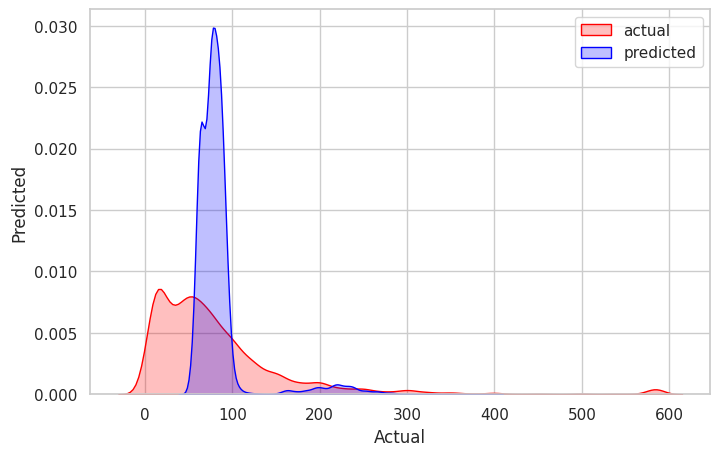

In [14]:
plt.figure(figsize=(8,5))
sns.kdeplot(y_test,color='red',fill=True,label='actual')
sns.kdeplot(y_pred,color='blue',fill=True,label='predicted')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

ValueError: 'block' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

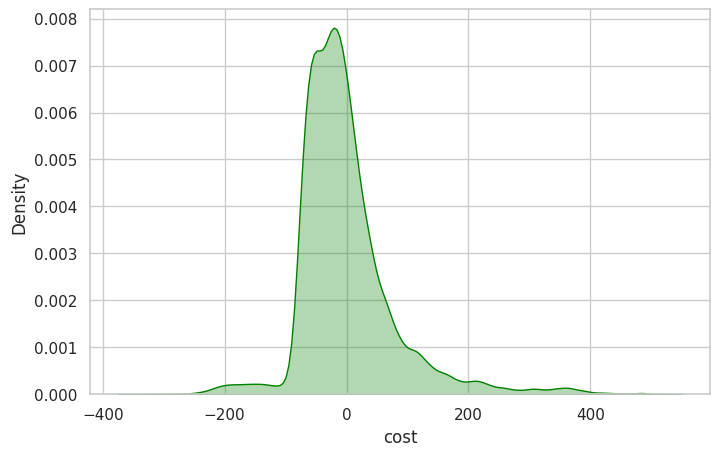

In [15]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

sns.kdeplot(errors,fill=True,alpha=0.3,color='green')
plt.axvline(x=0,color='block',linestyle='--',label='mean')
plt.axvline(x=errors.mean(),color='white',linestyle='--',label=f'Mean error: ${errors.mean():.2f}')

plt.xlabel('Prediction Error ($)')
plt.ylabel('Density')
plt.title('KDE: Prediction Error Distribution')
plt.legend()
plt.show()


In [17]:
print(df.head(10).to_string)

<bound method DataFrame.to_string of    index    newid reference_month  reference_year     ucc   cost  fam_size  \
0     29  4214954         January            2020  270102   45.0         1   
1     30  4214954        February            2020  270102   45.0         1   
2     31  4214954           March            2020  270102   45.0         1   
3     32  4214954         January            2020  690114  120.0         1   
4     33  4214954        February            2020  690114  120.0         1   
5     34  4214954           March            2020  690114  120.0         1   
6     35  4214964         January            2020  270102   56.0         2   
7     36  4214964        February            2020  270102   56.0         2   
8     37  4214964           March            2020  270102   56.0         2   
9     38  4214974         January            2020  270102   48.0         2   

   family_income_before_tax_last_12_month  calibration_weight  \
0                                   100

In [18]:
# 1. Unique values for categoricals
for col in ['reference_month', 'region', 'sex_ref', 'state', 'psu', 'division', 'product_category', 'population_size']:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].unique()[:20])

# 2. Basic stats
print(df.describe().to_string())


reference_month (12 unique):
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']

region (4 unique):
['West' 'Northeast' 'South' 'Midwest']

sex_ref (2 unique):
['Male' 'Female']

state (23 unique):
['California' 'New York' 'Colorado' 'Washington' 'Florida' 'Illinois'
 'Maryland' 'Georgia' 'Texas' 'Pennsylvania' 'Michigan' 'Alaska' 'Hawaii'
 'New Jersey' 'Minnesota' 'Arizona' 'Missouri' 'Massachusetts'
 'District of Columbia' 'Virginia']

psu (23 unique):
['Riverside-San Bernardino-Ontario, CA'
 'New York-Newark-Jersey City, NY-NJ-PA'
 'Los Angeles-Long Beach-Anaheim, CA' 'San Diego-Carlsbad, CA'
 'Denver-Aurora-Lakewood, CO' 'Seattle-Tacoma-Bellevue, WA'
 'Miami-Fort Lauderdale-West Palm Beach, FL'
 'Chicago-Naperville-Elgin, IL-IN-WI' 'Baltimore-Columbia-Towson, MD'
 'Atlanta-Sandy Springs-Roswell, GA'
 'Houston-The Woodlands-Sugar Land, TX'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD'
 'Detroit-Warren-Dearborn, MI' 'Tam

In [19]:
print(df.describe())

               index         newid  reference_year            ucc  \
count  262467.000000  2.624670e+05   262467.000000  262467.000000   
mean   295096.645853  4.820565e+06     2021.338759  406681.645247   
std    170298.020132  4.017315e+05        1.210964  184855.632877   
min        29.000000  4.214954e+06     2020.000000  270102.000000   
25%    148446.500000  4.465701e+06     2020.000000  270102.000000   
50%    294839.000000  4.748351e+06     2021.000000  310243.000000   
75%    441197.000000  5.252903e+06     2023.000000  690114.000000   
max    653400.000000  5.607981e+06     2023.000000  690330.000000   

                cost       fam_size  family_income_before_tax_last_12_month  \
count  262467.000000  262467.000000                            2.624670e+05   
mean       84.895726       2.542769                            1.097922e+05   
std        89.492778       1.476145                            1.149796e+05   
min         0.000000       1.000000                           

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262467 entries, 0 to 262466
Data columns (total 21 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   index                                   262467 non-null  int64  
 1   newid                                   262467 non-null  int64  
 2   reference_month                         262467 non-null  object 
 3   reference_year                          262467 non-null  int64  
 4   ucc                                     262467 non-null  int64  
 5   cost                                    262467 non-null  float64
 6   fam_size                                262467 non-null  int64  
 7   family_income_before_tax_last_12_month  262467 non-null  int64  
 8   calibration_weight                      262467 non-null  float64
 9   number_of_earners                       262467 non-null  int64  
 10  interview_month                         2624